In [3]:
%cd ..
import nibabel as nib
from  deepmrac.image_processing import sort_dicomfiles, load_and_resample_images, resample_to_output_format, to_dcm, convert_dicom_to_nifti, convert_interfile_to_nifti, to_interfile, transform_ct_to_mu511
from deepmrac.predictions import predict_DeepT1
from deepmrac.metrics import calculate_quality_metrics, save_metrics_to_csv
import numpy as np
import os

/Users/anne-gabrielle/Le_Neuro/DeepMRAC


# T1

In [26]:
tmpdir="./temp_file"
t1_path="./datasets/REMIND_003/T1/MPRAGE_0007"
umap_path="./datasets/REMIND_003/UTE/MRAC_UTE_UMAP_0021"
verbose=True
ct_path="./datasets/REMIND_014/CTAC"
output_folder=f"./output/T1/tests"
ct_kvp=120

In [20]:
# --- Process T1 (Standard DICOM) ---
sort_dicomfiles(source_folder=t1_path, temp_subfolder=f"{tmpdir}/t1_dcm", verbose=verbose)
convert_dicom_to_nifti(dicom_dir=f"{tmpdir}/t1_dcm", output_nii=f"{tmpdir}/t1.nii.gz", verbose=verbose)

Principal Serie identified : 1.3.12.2.1107.5.2.38.51018.2021071411001090283007097.0.0.0 (208 images)
Converting ./temp_file/t1_dcm to ./temp_file/t1.nii.gz


In [21]:
# --- Process UMAP (Conditional: DICOM or Interfile) ---
# Check if there's an Interfile header in the source folder
interfile_headers = [f for f in os.listdir(umap_path) if f.lower().endswith('.i.hdr')]

if interfile_headers:
    if verbose:
        print(f"Detected Interfile format for UMAP in {umap_path}")
    
    # We take the first header found
    hdr_full_path = os.path.join(umap_path, interfile_headers[0])

    convert_interfile_to_nifti(hdr_path=hdr_full_path, output_nii_path=f"{tmpdir}/umap.nii.gz")

else:
    if verbose:
        print(f"Detected DICOM format for UMAP in {umap_path}")
        
    # Standard sorting for DICOM files
    sort_dicomfiles(source_folder=umap_path, temp_subfolder=f"{tmpdir}/umap_dcm", verbose=verbose)
    convert_dicom_to_nifti(dicom_dir=f"{tmpdir}/umap_dcm", output_nii=f"{tmpdir}/umap.nii.gz", verbose=verbose)

Detected DICOM format for UMAP in ./datasets/REMIND_003/UTE/MRAC_UTE_UMAP_0021
Principal Serie identified : 1.3.12.2.1107.5.2.38.51018.2021071411323755865726389.0.0.0 (192 images)
Converting ./temp_file/umap_dcm to ./temp_file/umap.nii.gz


In [22]:
t1_rsl, t1_ref = load_and_resample_images(nii_image=f"{tmpdir}/t1.nii.gz", verbose=verbose)
umap_nat = nib.load(f'{tmpdir}/umap.nii.gz')


Loading and resampling data from ./temp_file/t1.nii.gz.


In [23]:
print(f"CT-Umap min : {umap_nat.get_fdata().min()}")
print(f"CT-Umap max : {umap_nat.get_fdata().max()}") 
print(f"CT-Umap shape : {umap_nat.get_fdata().shape}") 

CT-Umap min : 0.0
CT-Umap max : 1510.0
CT-Umap shape : (192, 192, 192)


In [24]:
# Flip to match orientation on what was trained on
t1_rsl = np.flipud(np.swapaxes(t1_rsl, 0, 2)) 

In [25]:
pred = predict_DeepT1(t1=t1_rsl, version='VE11P')
pred = np.swapaxes(np.flipud(pred), 2, 0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [27]:
print(f"sCT min : {pred.min()}")
print(f"sCT max : {pred.max()}") 
print(f"sCT shape : {pred.shape}") 

sCT min : 0.0
sCT max : 2558.12890625
sCT shape : (192, 192, 192)


In [28]:
pred = pred / 10000
print(f"sCT min : {pred.min()}")
print(f"sCT max : {pred.max()}") 
print(f"sCT shape : {pred.shape}") 

sCT min : 0.0
sCT max : 0.255812890625
sCT shape : (192, 192, 192)


In [29]:
# Resample: Umap Format
pred_nii = nib.Nifti1Image(pred, t1_ref.affine, t1_ref.header)
os.makedirs(output_folder, exist_ok=True)
DeepX_nii = resample_to_output_format(pred_nii=pred_nii, umap_native=umap_nat, verbose=verbose, output_file=f"{output_folder}/DeepT1.nii.gz")

Resampling to Umap format.
Saving QC nii file to ./output/T1/tests/DeepT1.nii.gz.


In [30]:
# Final DICOM (using Umap as container)
if interfile_headers:
    to_interfile(DeepX_nii=DeepX_nii, hdr_template=hdr_full_path, output_path=f"{output_folder}/DeepT1", rmi_type="T1")
else:
    to_dcm(DeepX_nii=DeepX_nii, dcmcontainer=f"{tmpdir}/umap_dcm", dicomfolder=f"{output_folder}/DeepT1", rmi_type="T1")

In [31]:
ctac_nii_resampled_path = None
if ct_path and os.path.exists(ct_path):
    is_nifti = ct_path.lower().endswith(('.nii', '.nii.gz'))

    if is_nifti:
        if verbose: print(f"CT is already NIfTI: {ct_path}")
        ct_nat = nib.load(ct_path)
    else:
        # DICOM files
        sort_dicomfiles(source_folder=ct_path, temp_subfolder=f"{tmpdir}/ct_dcm", verbose=verbose)
        convert_dicom_to_nifti(dicom_dir=f"{tmpdir}/ct_dcm", output_nii=f"{tmpdir}/ct.nii.gz", verbose=verbose)
        ct_nat = nib.load(f'{tmpdir}/ct.nii.gz')

    data_sample = ct_nat.get_fdata()
    min_val = np.min(data_sample)
    max_val = np.max(data_sample)

    # Check if the values correspond to CT or CTAC
    if min_val < -50:
        if verbose: 
            print(f"Detected CT data (HU range: {min_val:.1f} to {max_val:.1f}). Transforming to Mu511...")
        ctac_nat = transform_ct_to_mu511(ct_nat, kvp=ct_kvp)
    else:
        if max_val > 10:
            if verbose:
                print(f"Detected AC/U-map data (Range: {min_val:.4f} to {max_val:.4f}). Skipping CT transform and dividing by 10000.")
            new_data = data_sample / 10000.0
            ctac_nat = nib.Nifti1Image(new_data, ct_nat.affine, ct_nat.header)
        else:
            if verbose:
                print(f"Detected AC/U-map data (Range: {min_val:.4f} to {max_val:.4f}). Skipping CT transform.")
            ctac_nat = ct_nat

    ctac_nii_resampled_path = f"{output_folder}/CTAC_resampled.nii.gz"
    ctac_rsl = resample_to_output_format(pred_nii=ctac_nat, umap_native=umap_nat, verbose=verbose, output_file=ctac_nii_resampled_path)

    # Calculate metrics DeepT1 - CTAC
    metrics_dict = calculate_quality_metrics(
        smu_nii_path=f"{output_folder}/DeepT1.nii.gz",
        mu_nii_path=ctac_nii_resampled_path,
    )

    if verbose:
        print("\n" + "="*30)
        print(" GLOBAL QUALITY METRICS ")
        print("="*30)
        print(f"PSNR: {metrics_dict['PSNR']:.2f}")
        print(f"SSIM: {metrics_dict['SSIM']:.4f}")
                            
        for mode in ['tissue', 'bone']:
            print(f"\n--- {mode.upper()} ANALYSIS ---")
            print(f"MAE:  {metrics_dict[f'{mode}_MAE']:.4f}")
            print(f"ME:   {metrics_dict[f'{mode}_ME']:.4f}")
            print(f"RE:   {metrics_dict[f'{mode}_RE']:.4f}")
            print(f"ARE:  {metrics_dict[f'{mode}_ARE']:.4f}")
            print(f"Dice: {metrics_dict[f'{mode}_Dice']:.4f}")
        print("="*30)

    save_metrics_to_csv(metrics_dict=metrics_dict, rmi_type='DeepT1', output_folder=f"{output_folder}/metrics")

    # Calculate metrics T1 Umap - CTAC
    metrics_dict = calculate_quality_metrics(
            smu_nii_path=f'{tmpdir}/umap.nii.gz',
            mu_nii_path=ctac_nii_resampled_path,
    )

    save_metrics_to_csv(metrics_dict=metrics_dict, rmi_type='Template Umap', output_folder=f"{output_folder}/metrics")

Principal Serie identified : 1.3.12.2.1107.5.2.38.51018.2022120509092183019007704.0.0.0 (132 images)
Converting ./temp_file/ct_dcm to ./temp_file/ct.nii.gz
Detected AC/U-map data (Range: 0.0000 to 1857.0000). Skipping CT transform and dividing by 10000.
Resampling to Umap format.
Saving QC nii file to ./output/T1/tests/CTAC_resampled.nii.gz.
sUmap Range: 0.00 to 0.25
Umap Range: 0.00 to 0.18

 GLOBAL QUALITY METRICS 
PSNR: 17.99
SSIM: 0.8148

--- TISSUE ANALYSIS ---
MAE:  0.0272
ME:   -0.0174
RE:   -0.1501
ARE:  0.2472
Dice: 0.7285

--- BONE ANALYSIS ---
MAE:  0.1194
ME:   -0.1181
RE:   -0.7693
ARE:  0.7778
Dice: 0.0059
Metrics saved at : ./output/T1/tests/metrics/all_metrics.csv
sUmap Range: 0.00 to 1510.00
Umap Range: 0.00 to 0.18
Metrics saved at : ./output/T1/tests/metrics/all_metrics.csv


# Visualization

In [32]:
from deepmrac.plots import plot_comparison

Plot saved to: ./output/T1/tests/comparison_plot.png


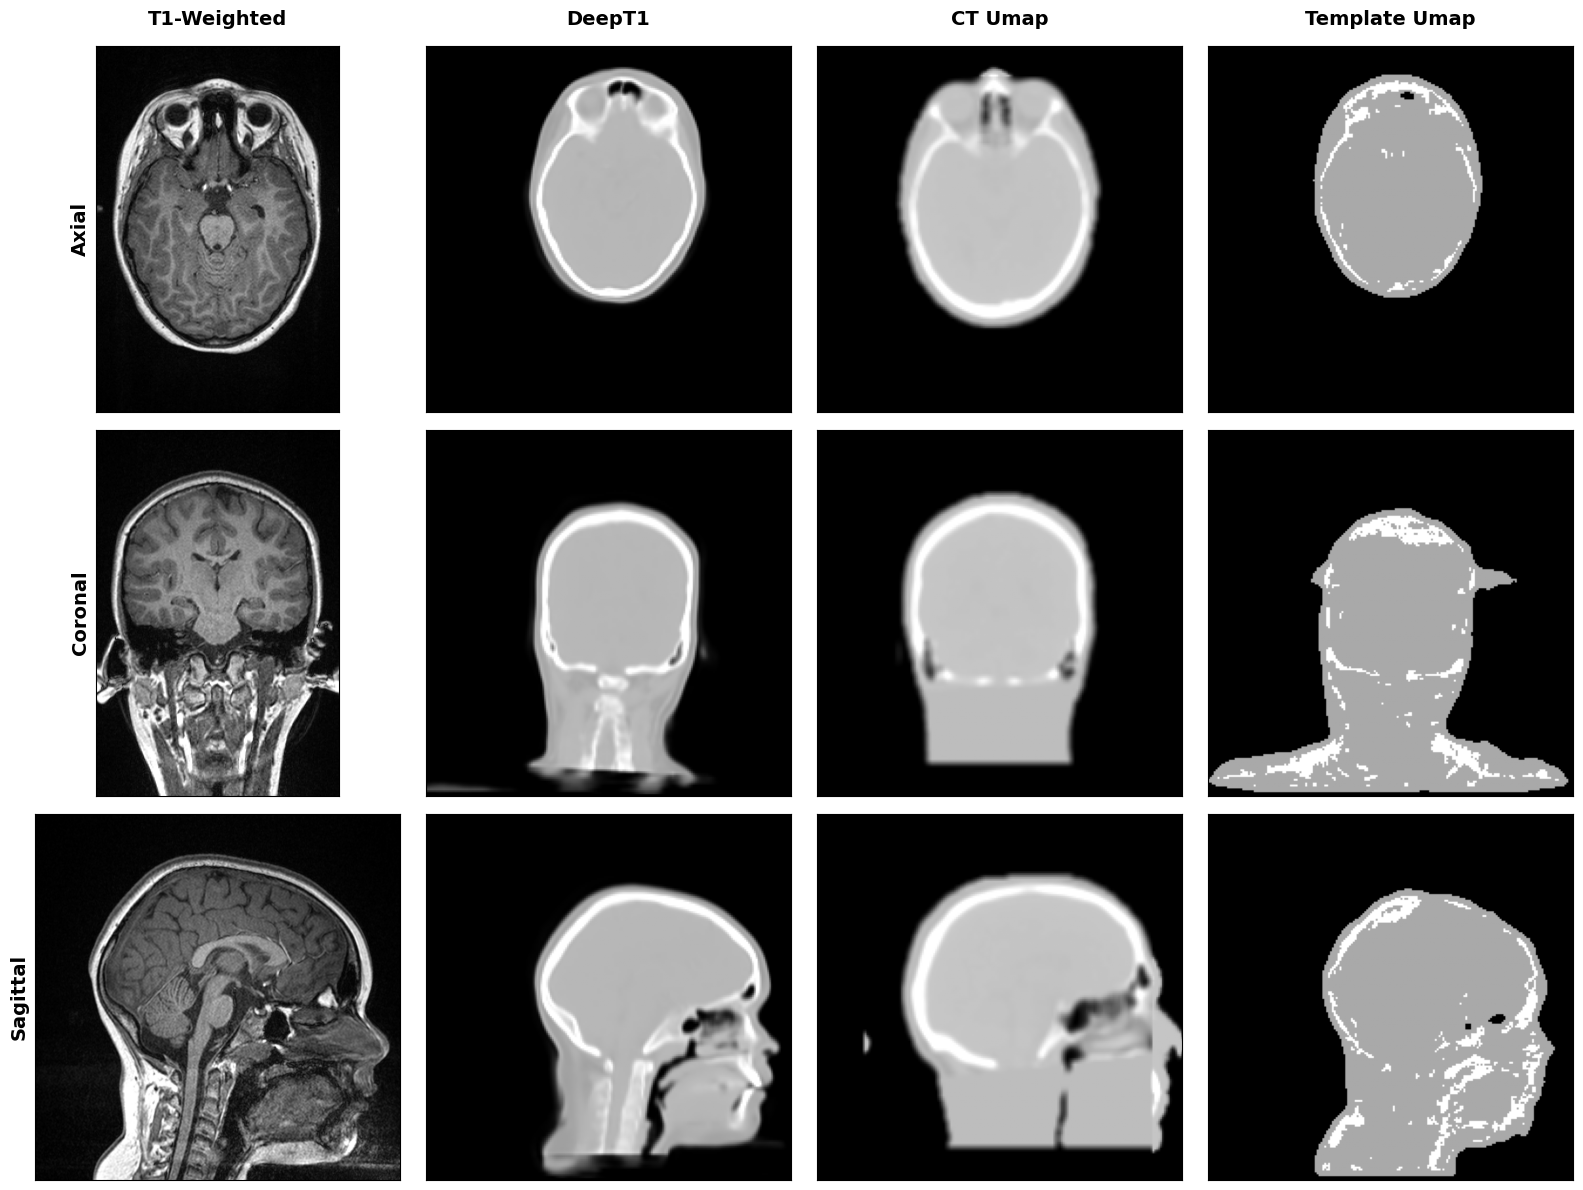

In [33]:
plot_comparison(input_path=f"{tmpdir}/t1.nii.gz", prediction_path=f"{output_folder}/DeepT1.nii.gz", template_umap_path=f'{tmpdir}/umap.nii.gz', model_type="T1", ctac_path=ctac_nii_resampled_path, output_path=f"{output_folder}/comparison_plot.png")